In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('/content/order_history_kaggle_data.csv')
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


## Limpeza Dados

###Conversão de Datas

In [3]:
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], format='%I:%M %p, %B %d %Y')
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


### Limpeza da Coluna de Distância

In [4]:
df['Distance'] = df['Distance'].str.replace('km', '', regex=False)
df['Distance'] = df['Distance'].str.replace('<1', '0.5', regex=False)
df['Distance'] = df['Distance'].astype(float)
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,0.5,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


### Criação de Variáveis (Feature Engineering)

Extrair Hora do Dia, Dia da Semana e Mês a partir da data do pedido.

In [5]:
df['Order Time'] = df['Order Placed At'].dt.strftime('%H:%M:%S')
df['Order Date'] = df['Order Placed At'].dt.date
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID,Order Time,Order Date
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,23:38:00,2024-09-10
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,23:34:00,2024-09-10
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,0.5,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,15:52:00,2024-09-10
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,15:45:00,2024-09-10
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,15:04:00,2024-09-10


In [6]:
df['Order Hour'] = df['Order Placed At'].dt.hour
df['Order Month'] = df['Order Placed At'].dt.month_name()
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID,Order Time,Order Date,Order Hour,Order Month
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,23:38:00,2024-09-10,23,September
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,23:34:00,2024-09-10,23,September
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,0.5,1 x Bone in Peri Peri Grilled Chicken,...,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,15:52:00,2024-09-10,15,September
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,15:45:00,2024-09-10,15,September
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,15:04:00,2024-09-10,15,September


Criar uma coluna de Desconto Total somando todos os campos de desconto disponíveis.

In [7]:
df['Brand pack discount'] = pd.to_numeric(df['Brand pack discount'], errors='coerce').fillna(0)
df['Gold discount'] = pd.to_numeric(df['Gold discount'], errors='coerce').fillna(0)
df['Restaurant discount (Flat offs, Freebies & others)'] = pd.to_numeric(df['Restaurant discount (Flat offs, Freebies & others)'], errors='coerce').fillna(0)
df['Restaurant discount (Promo)'] = pd.to_numeric(df['Restaurant discount (Promo)'], errors='coerce').fillna(0)

df['Desconto Total'] = df['Brand pack discount'] + df['Gold discount'] + df['Restaurant discount (Flat offs, Freebies & others)'] + df['Restaurant discount (Promo)']
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID,Order Time,Order Date,Order Hour,Order Month,Desconto Total
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,23:38:00,2024-09-10,23,September,80.0
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,23:34:00,2024-09-10,23,September,175.0
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,0.5,1 x Bone in Peri Peri Grilled Chicken,...,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,15:52:00,2024-09-10,15,September,80.0
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,15:45:00,2024-09-10,15,September,80.0
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,15:04:00,2024-09-10,15,September,80.0


### Padronização de Strings

Garantir que nomes de cidades e subzonas não tenham espaços extras ou variações de grafia.

In [8]:
df['City'] = df['City'].str.strip().str.capitalize()
df['Subzone'] = df['Subzone'].str.strip().str.capitalize()
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID,Order Time,Order Date,Order Hour,Order Month,Desconto Total
0,20320607,Swaad,Sector 4,Delhi ncr,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,23:38:00,2024-09-10,23,September,80.0
1,20320607,Swaad,Sector 4,Delhi ncr,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,23:34:00,2024-09-10,23,September,175.0
2,20320607,Swaad,Sector 4,Delhi ncr,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,0.5,1 x Bone in Peri Peri Grilled Chicken,...,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,15:52:00,2024-09-10,15,September,80.0
3,20320607,Swaad,Sector 4,Delhi ncr,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,15:45:00,2024-09-10,15,September,80.0
4,20320607,Swaad,Sector 4,Delhi ncr,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,15:04:00,2024-09-10,15,September,80.0


## Análise Descritiva

### Volume de Pedidos

Volume de pedidos pelo tempo

In [9]:
# Ensure 'Order Day of Week' column exists
df['Order Day of Week'] = df['Order Placed At'].dt.day_name()

# Order volume by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_orders = df['Order Month'].value_counts().reindex(month_order, fill_value=0)

print("\nVolume de pedidos por mês:")
print(monthly_orders[monthly_orders > 0]) # Display only months with orders


Volume de pedidos por mês:
Order Month
January      4011
September    4241
October      4277
November     4491
December     4301
Name: count, dtype: int64


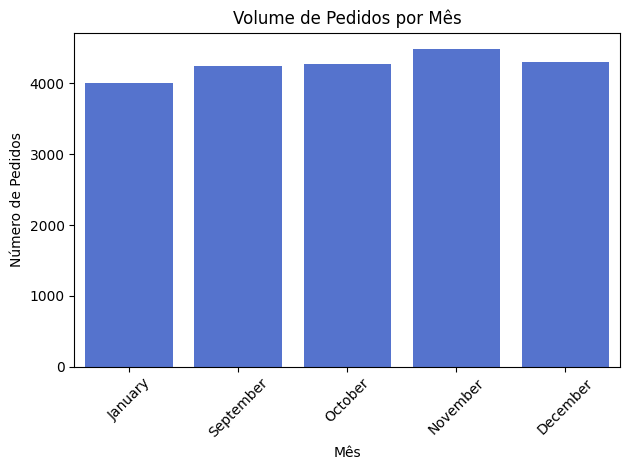

In [10]:
sns.barplot(
    x=monthly_orders[monthly_orders > 0].index,
    y=monthly_orders[monthly_orders > 0].values,
    color='royalblue'
)

plt.title('Volume de Pedidos por Mês')
plt.xlabel('Mês')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Volume de pedidos por dia da semana:
Order Day of Week
Monday       2196
Tuesday      2885
Wednesday    3077
Thursday     2879
Friday       3403
Saturday     3923
Sunday       2958
Name: count, dtype: int64


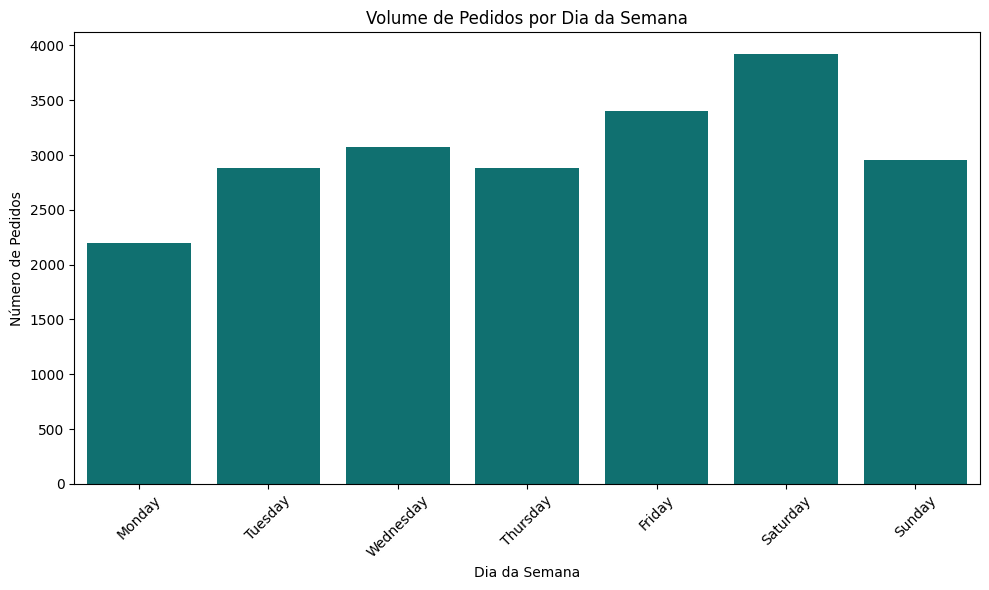

In [12]:
# Volume de pedidos por dia da semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_orders = df['Order Day of Week'].value_counts().reindex(day_order, fill_value=0)

print("\nVolume de pedidos por dia da semana:")
print(daily_orders)

plt.figure(figsize=(10, 6))

sns.barplot(x=daily_orders.index, y=daily_orders.values, color='teal')

plt.title('Volume de Pedidos por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Métricas Financeiras

In [15]:
average_order_total = df['Total'].mean()
average_subtotal = df['Bill subtotal'].mean()

print(f"Valor Médio Total Recebido (Total): ${average_order_total:,.2f}")
print(f"Valor Médio Total Sem Desconto (Bill Subtotal): ${average_subtotal:,.2f}")

Valor Médio Total Recebido (Total): $682.62
Valor Médio Total Sem Desconto (Bill Subtotal): $750.08


### Logística

Dados como Distância Média, Tempo de Preparo (KPT) e Tempo de Espera do Entregador

In [18]:
average_distance = df['Distance'].mean()
average_kpt_duration = df['KPT duration (minutes)'].mean()
average_rider_wait_time = df['Rider wait time (minutes)'].mean()

print(f"Distância Média: {average_distance:,.2f} km.")
print(f"Tempo de Preparo (KPT): Média de {average_kpt_duration:,.1f} minutos.")
print(f"Tempo de Espera do Entregador: Média de {average_rider_wait_time:,.1f} minutos.")

Distância Média: 4.17 km.
Tempo de Preparo (KPT): Média de 17.3 minutos.
Tempo de Espera do Entregador: Média de 4.8 minutos.


### Satisfação

A nota média e taxa de resposta

In [19]:
average_rating = df['Rating'].mean()
rating_response_rate = df['Rating'].count() / len(df) * 100

print(f"Nota Média de Avaliação: {average_rating:,.2f} / 5.0")
print(f"Taxa de Resposta de Avaliação: {rating_response_rate:,.2f}%")

Nota Média de Avaliação: 4.36 / 5.0
Taxa de Resposta de Avaliação: 11.68%


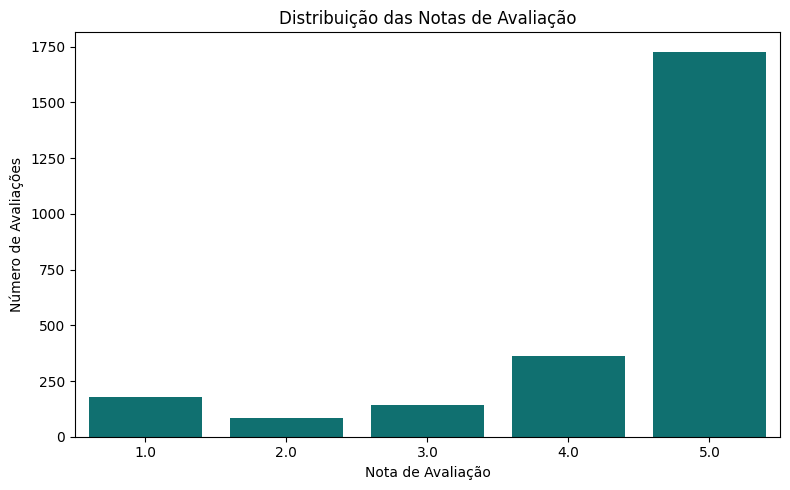

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Rating', data=df, color='teal')

plt.title('Distribuição das Notas de Avaliação')
plt.xlabel('Nota de Avaliação')
plt.ylabel('Número de Avaliações')
plt.tight_layout()
plt.show()


In [21]:
# Re-display the average rating and response rate for context
average_rating = df['Rating'].mean()
rating_response_rate = df['Rating'].count() / len(df) * 100
print(f"\nNota Média de Avaliação: {average_rating:,.2f} / 5.0")
print(f"Taxa de Resposta de Avaliação: {rating_response_rate:,.2f}%")


Nota Média de Avaliação: 4.36 / 5.0
Taxa de Resposta de Avaliação: 11.68%


### Status dos Pedido

In [15]:
order_status_counts = df['Order Status'].value_counts()

print("\nContagem de Status dos Pedidos (Tabela):")
print(order_status_counts)


Contagem de Status dos Pedidos (Tabela):
Order Status
Delivered           21131
Rejected              158
Returned               25
Return cancelled        3
Picked up               3
Timed out               1
Name: count, dtype: int64


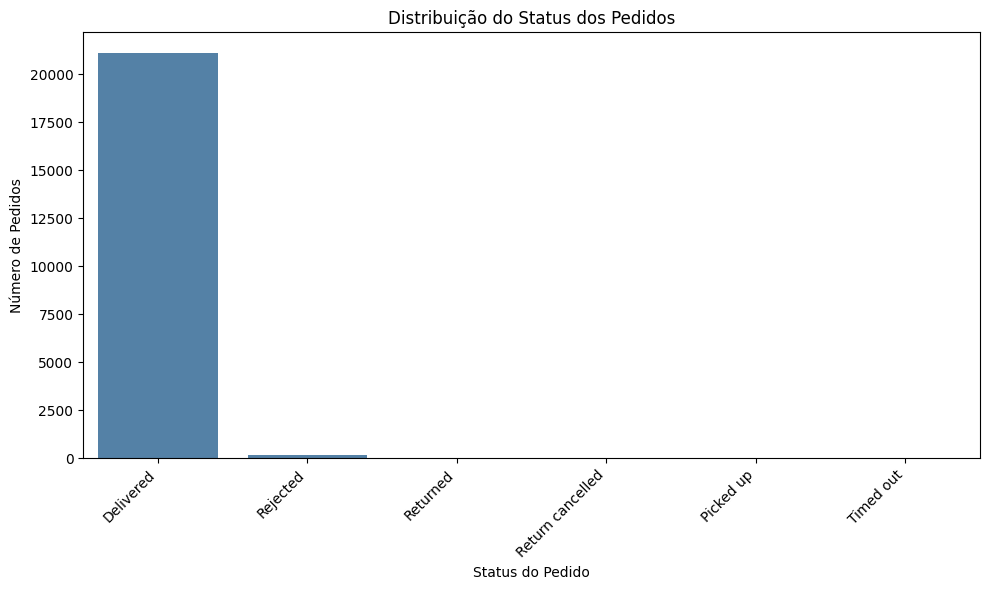

In [16]:
# Gráfico 1: Status Geral
plt.figure(figsize=(10, 6))

sns.barplot(x=order_status_counts.index, y=order_status_counts.values, color='steelblue')

plt.title('Distribuição do Status dos Pedidos')
plt.xlabel('Status do Pedido')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
non_delivered_status = order_status_counts.drop('Delivered', errors='ignore')

print("\nContagem de Status dos Pedidos (Excluindo 'Delivered'):")
print(non_delivered_status)


Contagem de Status dos Pedidos (Excluindo 'Delivered'):
Order Status
Rejected            158
Returned             25
Return cancelled      3
Picked up             3
Timed out             1
Name: count, dtype: int64


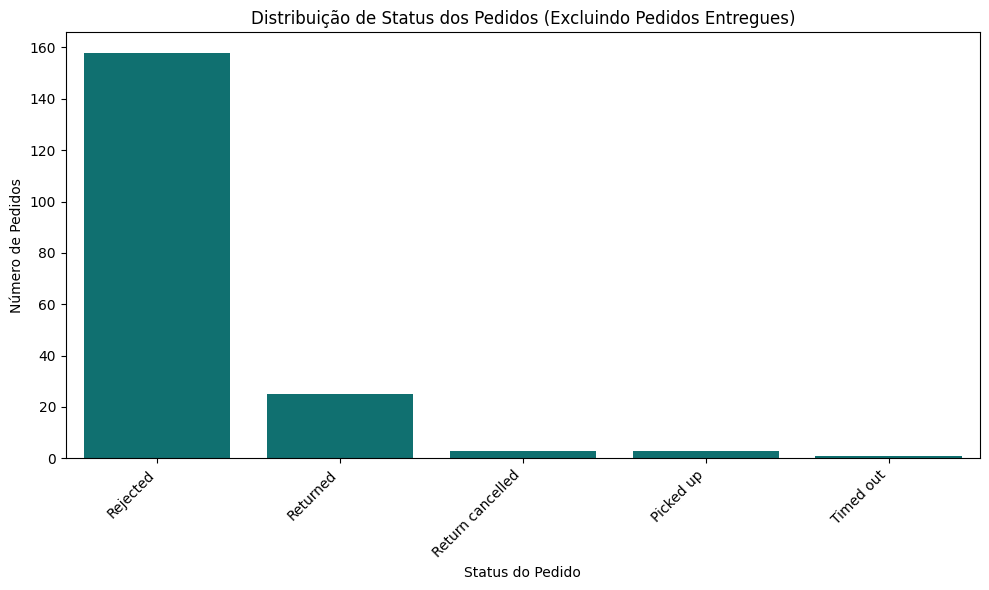

In [18]:
# Gráfico 2: Status Excluindo Entregues
plt.figure(figsize=(10, 6))

sns.barplot(x=non_delivered_status.index, y=non_delivered_status.values, color='teal')

plt.title('Distribuição de Status dos Pedidos (Excluindo Pedidos Entregues)')
plt.xlabel('Status do Pedido')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Análises

### Análise de Sazonalidade e Horários de Pico:

Identificar quais horas do dia concentram o maior volume de vendas para otimizar o estoque e a equipe de cozinha.

In [19]:
order_volume_by_hour = df['Order Hour'].value_counts().sort_index()

print("\nVolume de Pedidos por Hora do Dia:")
print(order_volume_by_hour)


Volume de Pedidos por Hora do Dia:
Order Hour
0      957
1      833
2      488
3      389
4        5
11     305
12     909
13    1142
14    1032
15     824
16     905
17    1069
18    1611
19    2419
20    2912
21    2296
22    1748
23    1477
Name: count, dtype: int64


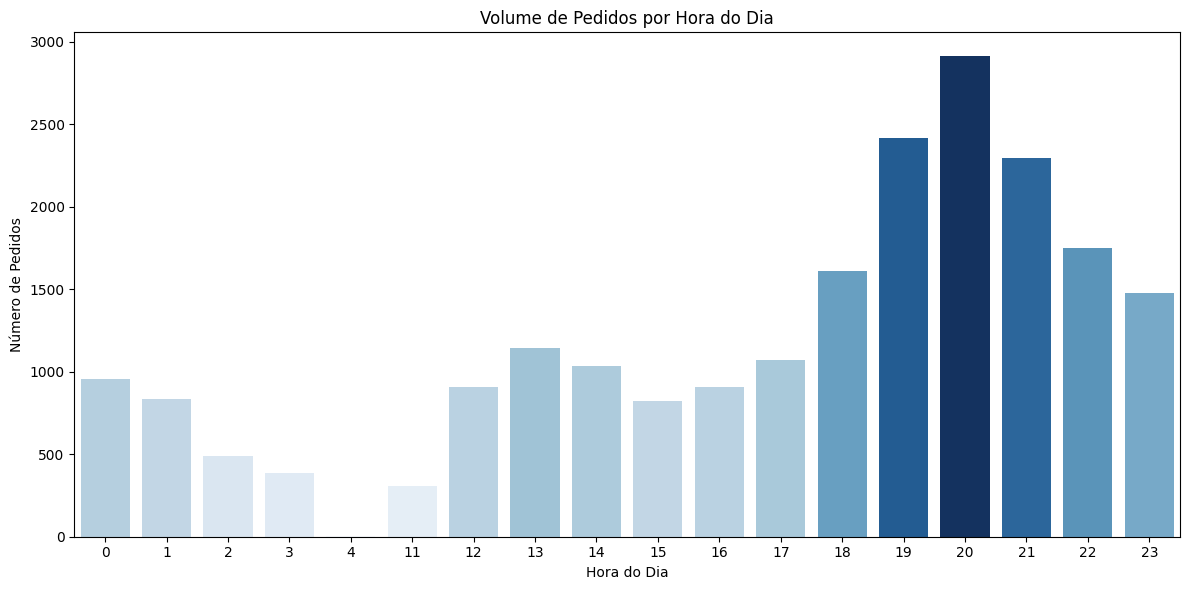

In [20]:
plt.figure(figsize=(12, 6))

# legend=False remove a legenda automática que seria criada para os valores
sns.barplot(
    x=order_volume_by_hour.index,
    y=order_volume_by_hour.values,
    hue=order_volume_by_hour.values,
    palette='Blues',
    legend=False
)

plt.title('Volume de Pedidos por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=0) # Horas costumam ficar melhores sem rotação se houver espaço
plt.tight_layout()
plt.show()

###Análise de Eficiência Operacional:

Correlacionar a Distance com o Rider wait time para entender se locais mais distantes causam gargalos logísticos.

In [21]:
correlation_distance_rider_wait = df['Distance'].corr(df['Rider wait time (minutes)'])
print(f"Correlação entre Distância e Tempo de Espera do Entregador: {correlation_distance_rider_wait:,.2f}")

Correlação entre Distância e Tempo de Espera do Entregador: 0.06


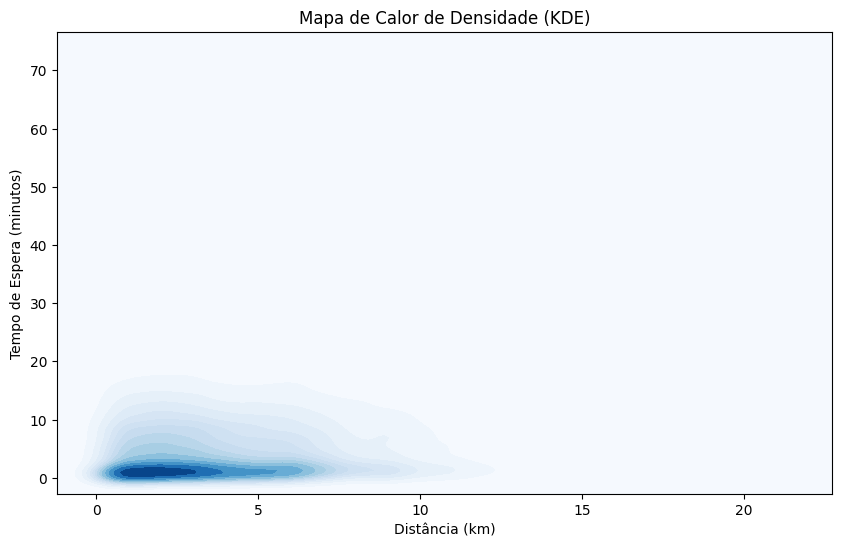

In [25]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    x='Distance',
    y='Rider wait time (minutes)',
    data=df,
    fill=True,
    thresh=0,
    levels=15,
    cmap='Blues'
)

plt.title('Mapa de Calor de Densidade (KDE)')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de Espera (minutos)')
plt.show()

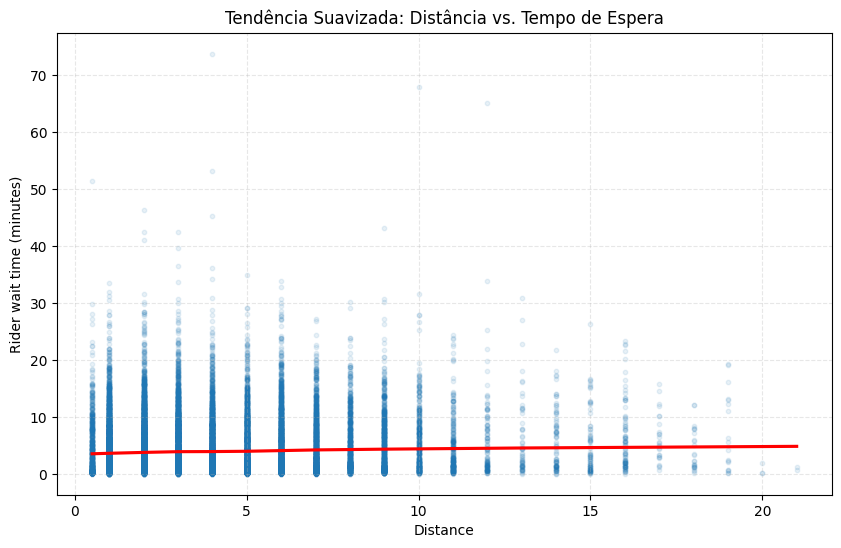

In [26]:
plt.figure(figsize=(10, 6))

# s=10 diminui o tamanho dos pontos
# order=2 tenta capturar curvas se a relação não for perfeitamente linear
sns.regplot(
    x='Distance',
    y='Rider wait time (minutes)',
    data=df,
    scatter_kws={'alpha':0.1, 's':10},
    line_kws={'color':'red'},
    lowess=True  # Cria uma linha que segue melhor a tendência local (suavizada)
)

plt.title('Tendência Suavizada: Distância vs. Tempo de Espera')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Verificar se o tempo de preparo (KPT) aumenta em dias de alto volume.

In [31]:
average_kpt_by_day = df.groupby('Order Day of Week')['KPT duration (minutes)'].mean().reindex(day_order)
print("\nAverage KPT Duration by Day of the Week:")
print(average_kpt_by_day)


Average KPT Duration by Day of the Week:
Order Day of Week
Monday       16.472524
Tuesday      17.385580
Wednesday    17.603800
Thursday     16.926909
Friday       17.509550
Saturday     18.034222
Sunday       16.906180
Name: KPT duration (minutes), dtype: float64


###Análise de Descontos e Rentabilidade:

Calcular o impacto dos descontos (Gold, Brand pack, Promo) no valor final.




In [33]:
average_impact_on_final_value = (df['Bill subtotal'] - df['Total']).mean()

print(f"Valor Médio do Impacto dos Descontos no Valor Final (Bill subtotal - Total): ${average_impact_on_final_value:,.2f}")


Valor Médio do Impacto dos Descontos no Valor Final (Bill subtotal - Total): $67.46


###Verificar se pedidos com maiores descontos resultam em melhores avaliações (Rating).

In [34]:
correlation_discount_rating = df['Desconto Total'].corr(df['Rating'])
print(f"Correlação entre 'Desconto Total' e 'Rating': {correlation_discount_rating:,.2f}")



Correlação entre 'Desconto Total' e 'Rating': 0.02


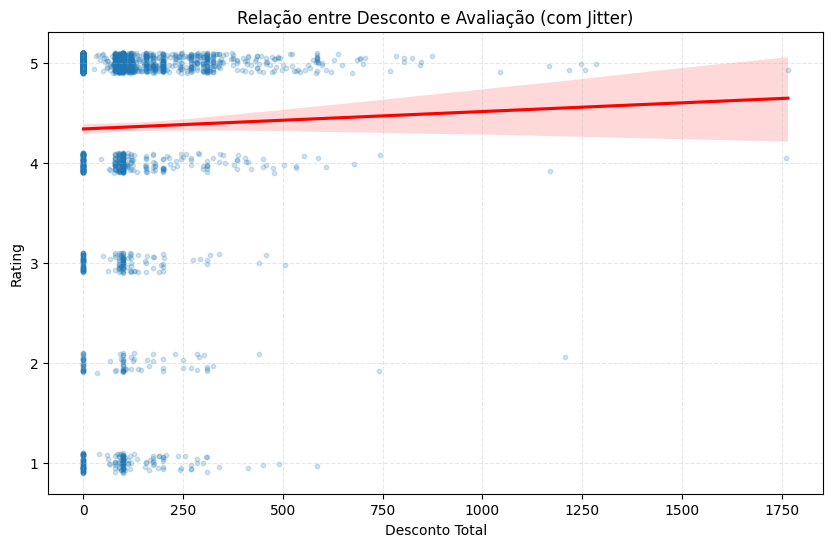

In [27]:
plt.figure(figsize=(10, 6))

# x_jitter e y_jitter espalham os pontos levemente para mostrar densidade
sns.regplot(
    x='Desconto Total',
    y='Rating',
    data=df,
    x_jitter=0.1,
    y_jitter=0.1,
    scatter_kws={'alpha':0.2, 's':10},
    line_kws={'color':'red'}
)

plt.title('Relação entre Desconto e Avaliação (com Jitter)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

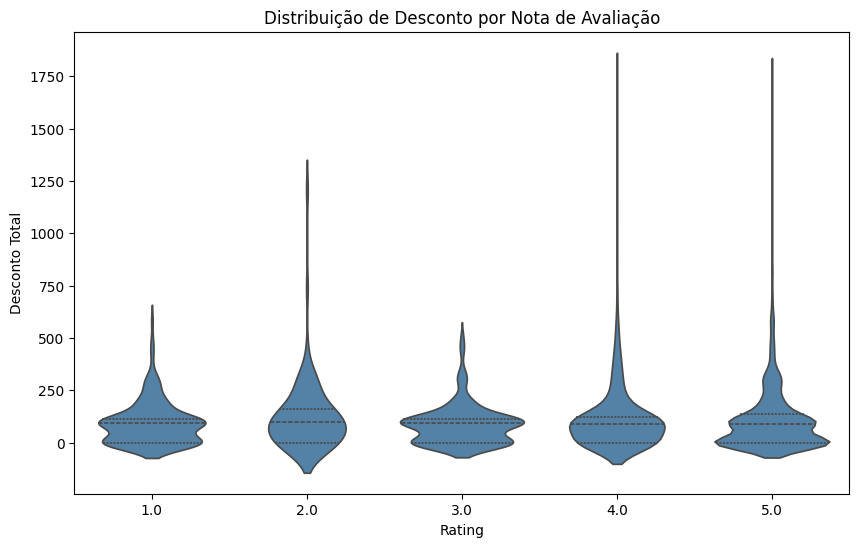

In [28]:
plt.figure(figsize=(10, 6))

# Violin plot mostra a distribuição (largura) do desconto para cada nota
sns.violinplot(x='Rating', y='Desconto Total', data=df, color='steelblue', inner='quartile')

plt.title('Distribuição de Desconto por Nota de Avaliação')
plt.show()

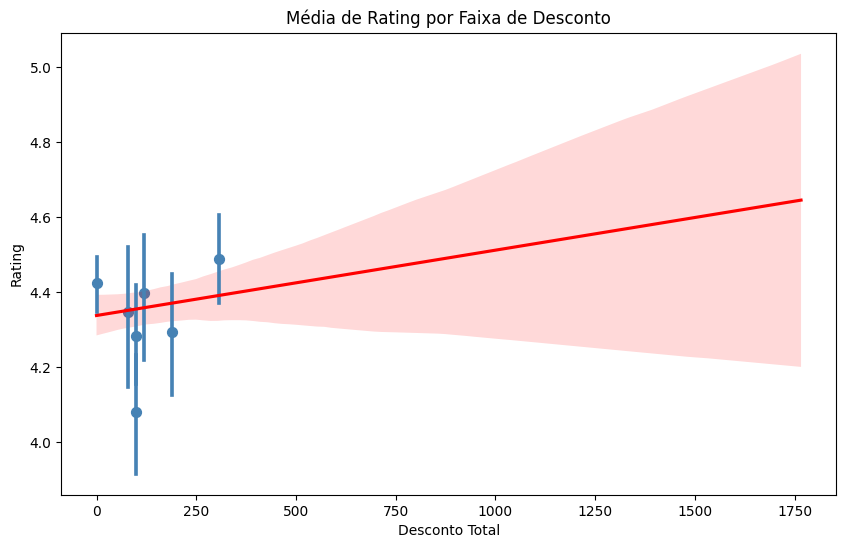

In [29]:
plt.figure(figsize=(10, 6))

# x_bins divide o desconto em 10 partes e mostra a média e o intervalo de confiança
sns.regplot(
    x='Desconto Total',
    y='Rating',
    data=df,
    x_bins=10,
    color='steelblue',
    line_kws={'color':'red'}
)

plt.title('Média de Rating por Faixa de Desconto')
plt.show()

###Comportamento do Cliente:

Analisar a recorrência de Customer ID para identificar clientes fiéis e criar estratégias de retenção.

In [36]:
customer_recurrence = df['Customer ID'].value_counts()

print("\nDistribuição da Recorrência de Pedidos por Cliente:")
print(customer_recurrence.value_counts().sort_index())


Distribuição da Recorrência de Pedidos por Cliente:
count
1     7713
2     1906
3      824
4      435
5      254
6      134
7      106
8       59
9       48
10      33
11      22
12      19
13       8
14       5
15       8
16       3
17       2
18       3
19       4
20       4
21       5
22       1
23       1
24       1
28       2
29       3
31       2
38       1
61       1
Name: count, dtype: int64


In [37]:
# Display top 10 most frequent customers
print("\nTop 10 Clientes Mais Frequentes:")
print(customer_recurrence.head(10))


Top 10 Clientes Mais Frequentes:
Customer ID
c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35dd5930ede1d8a643da    61
b64eade2d814bda0a3b16234e44400a4a9c0c44e5d6738a42e9e3c62b3d25723    38
6c24d2044b9eb120a8ad72e45545bc27569094def10dcf1b71d20b7ba75daefa    31
33c69b7971ae28ea3dd843fb16892339784847f361efd87f6b09beffe4968d53    31
12b07b9c3370baa5dd15fbfbc43c3dbc379fe66f73dbda9526c651d3fe501507    29
533c3ddab33a37b1d589e5cf1ff48d6aa10a2a8f7b9c5a5af548a9f978bdc22d    29
a7ffcb9e4f91fbff5baeddce59654687d99e418568dacce9c177aea47b9ce8fc    29
4f0c8bb49d63ece05f5a6e04183b590b0add9efc83dbd4179e2960d917920216    28
d8180eb413b840a12e04c206ba24718d947514b5bfaa638a0c6116af9eb902f9    28
7e6a43025a212e2963194375ab8b8ef5737f66ec414415538672ba3de04cc3a4    24
Name: count, dtype: int64


###Análise de Cancelamentos e Reclamações:

Investigar os motivos em Cancellation / Rejection reason para reduzir perdas operacionais.


In [31]:
cancellation_rejection_reasons = df['Cancellation / Rejection reason'].value_counts(dropna=True)

print("\nMotivos de Cancelamento / Rejeição:")
print(cancellation_rejection_reasons)



Motivos de Cancelamento / Rejeição:
Cancellation / Rejection reason
Cancelled by Customer    89
Cancelled by Zomato      81
Merchant device issue    12
Kitchen is full           3
Items out of stock        1
Name: count, dtype: int64


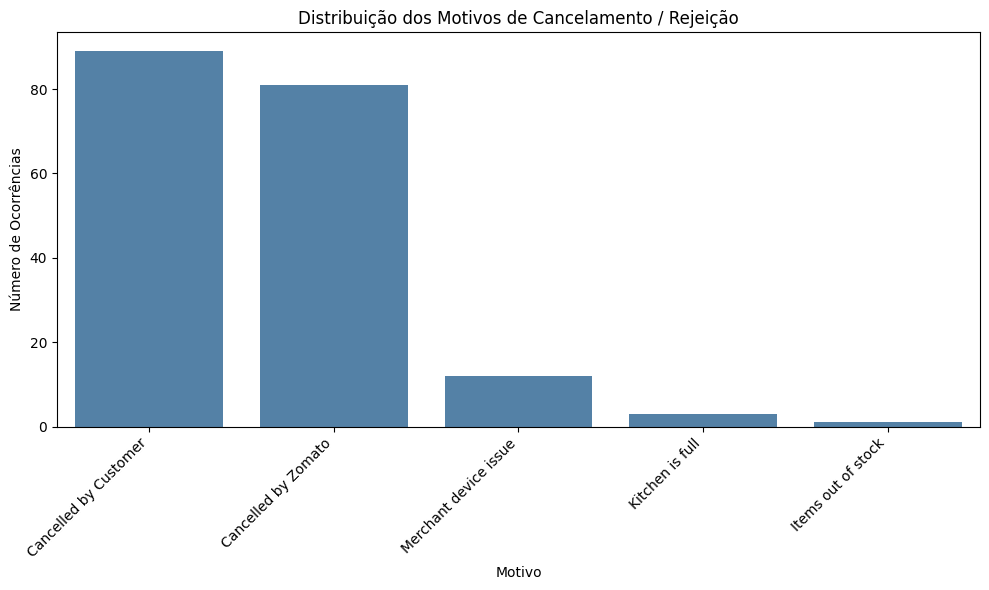

In [32]:
plt.figure(figsize=(10, 6))

# Trocado palette='coolwarm' por color='steelblue'
sns.barplot(
    x=cancellation_rejection_reasons.index,
    y=cancellation_rejection_reasons.values,
    color='steelblue'
)

plt.title('Distribuição dos Motivos de Cancelamento / Rejeição')
plt.xlabel('Motivo')
plt.ylabel('Número de Ocorrências')

# O ha='right' ajuda muito na legibilidade quando os nomes dos motivos são longos
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


###Análise de sentimentos básica nos textos da coluna Review.


Análise de Sentimentos:
Média da Polaridade do Sentimento: 0.20

Distribuição do Sentimento:
Sentiment
Neutral     21071
Positive      170
Negative       80
Name: count, dtype: int64


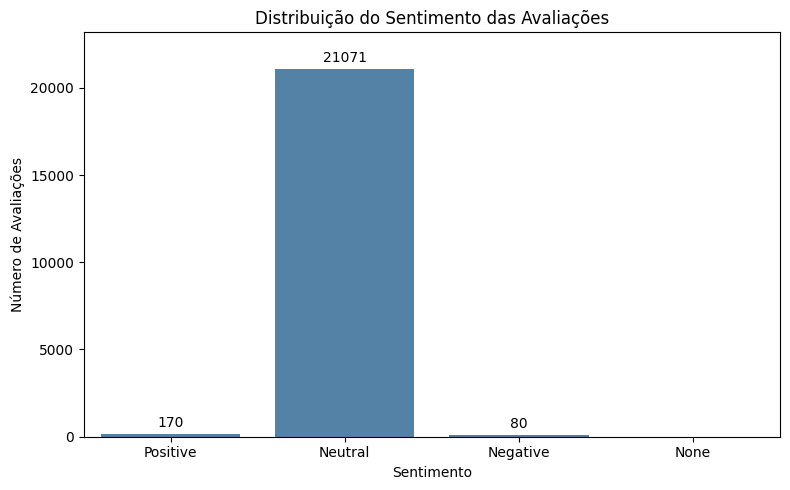

In [33]:
from textblob import TextBlob

def get_sentiment(text):
    if pd.isna(text):
        return None
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity

df['Sentiment_Polarity'] = df['Review'].apply(get_sentiment)

# Classify sentiment as Positive, Negative, or Neutral
def classify_sentiment(polarity):
    if polarity is None:
        return 'None'
    elif polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Sentiment_Polarity'].apply(classify_sentiment)

print("\nAnálise de Sentimentos:")
print(f"Média da Polaridade do Sentimento: {df['Sentiment_Polarity'].mean():.2f}")
print("\nDistribuição do Sentimento:")
print(df['Sentiment'].value_counts())

plt.figure(figsize=(8, 5))

# Criamos o objeto 'ax' para conseguir acessar as barras e colocar os rótulos
ax = sns.countplot(
    x='Sentiment',
    data=df,
    color='steelblue',
    order=['Positive', 'Neutral', 'Negative', 'None']
)

# Adiciona os valores acima das barras
# padding=3 define a distância entre o topo da barra e o texto
ax.bar_label(ax.containers[0], padding=3)

plt.title('Distribuição do Sentimento das Avaliações')
plt.xlabel('Sentimento')
plt.ylabel('Número de Avaliações')

# Aumenta o limite do eixo Y um pouco para o texto não ficar cortado no topo
plt.margins(y=0.1)

plt.tight_layout()
plt.show()